<a href="https://colab.research.google.com/github/akshaymeh7-web/passport-index-panel-regression/blob/main/passport_ranking_determinants.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Determinants of Passport Strength — A Panel Data Analysis
### Replication and Extension of MSc Dissertation Research
### Akshay Meher

---

This notebook replicates and extends the panel data econometric analysis from my MSc dissertation examining the macroeconomic and political determinants of passport strength across 191 countries
over 15 years (2009–2023).

**Research Question:** What macroeconomic and political factors determine a country's passport strength,
as measured by the Henley Passport Index?

**Key Finding:** GDP per capita is the dominant within-country predictor of passport strength,
consistent with the original dissertation finding. Unemployment emerges as a significant secondary predictor.

**Data Sources:** Henley Passport Index, World Bank Development Indicators,
Global Peace Index, Press Freedom Index

**Methodology:** Fixed Effects Panel OLS with clustered standard errors,
Granger causality testing, Hausman test, Cook's Distance outlier detection.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


After running the above cell and following the instructions to authorize Google Drive, your Drive will be mounted at `/content/drive`. You can then access files from your Drive. For example, to load a CSV file named `my_data.csv` located in the root of your Google Drive, you would use:

```python
import pandas as pd
file_path = '/content/drive/MyDrive/my_data.csv'
df = pd.read_csv(file_path)
display(df.head())
```

Remember to replace `my_data.csv` with the actual path and name of your file.

In [ ]:
import pandas as pd

file_path = '/content/drive/MyDrive/university of colorado/master data vertical-2.xlsx'
df = pd.read_excel(file_path)

display(df.head())

,Afghanistan,Asia,2008,Passport,89
0,Afghanistan,Asia,2008.0,Access,22
1,Afghanistan,Asia,2008.0,GPI,160
2,Afghanistan,Asia,2008.0,GPFI,156
3,Afghanistan,Asia,2008.0,GDPperCapita,382.533807
4,Afghanistan,Asia,2008.0,Tradevolume,0


### 1. Data Loading

The dataset is sourced from a compiled Excel file containing panel data across
199 countries spanning 2008 to 2023. The raw data is in stacked long format —
each row represents one country, one year, and one indicator value.

**Variables included:**
- Passport Score - Henley Passport Index rank (dependent variable)
- GDP per Capita - World Bank current USD
- Global Peace Index (GPI) - Institute for Economics and Peace
- Press Freedom Index (GPFI) - Reporters Without Borders
- Trade Volume - World Bank
- Inflation - World Bank
- Unemployment - World Bank

**Raw data structure:** 27,461 rows × 5 columns
(country, continent, year, indicator type, value)

In [ ]:
import os

directory_path = '/content/drive/MyDrive/university_of_colorado'

if os.path.exists(directory_path):
    print(f"Contents of '{directory_path}':")
    for item in os.listdir(directory_path):
        print(item)
else:
    print(f"Directory not found: '{directory_path}'")

Directory not found: '/content/drive/MyDrive/university_of_colorado'


In [ ]:
print(df.shape)
print(df.columns.tolist())
print(df.head())

(27461, 5)
['Afghanistan', 'Asia', 2008, 'Passport', 89]
   Afghanistan  Asia    2008      Passport          89
0  Afghanistan  Asia  2008.0        Access          22
1  Afghanistan  Asia  2008.0           GPI         160
2  Afghanistan  Asia  2008.0          GPFI         156
3  Afghanistan  Asia  2008.0  GDPperCapita  382.533807
4  Afghanistan  Asia  2008.0   Tradevolume           0


In [ ]:
import pandas as pd
import numpy as np

# Step 1 - Rename columns cleanly
df.columns = ['country', 'continent', 'year', 'indicator', 'value']

# Step 2 - Convert value to numeric
df['value'] = pd.to_numeric(df['value'], errors='coerce')

# Step 3 - Pivot to wide format
df_wide = df.pivot_table(
    index=['country', 'year'],
    columns='indicator',
    values='value'
).reset_index()

# Step 4 - Flatten column names
df_wide.columns.name = None

# Step 5 - Combine Passport and passport columns
if 'passport' in df_wide.columns:
    df_wide['Passport'] = df_wide['Passport'].combine_first(
        df_wide['passport']
    )
    df_wide = df_wide.drop(columns=['passport'])

# Step 6 - Drop Access variable
if 'Access' in df_wide.columns:
    df_wide = df_wide.drop(columns=['Access'])

# Step 7 - Filter to 2008-2023
df_wide = df_wide[df_wide['year'].between(2008, 2023)]

# Step 8 - Confirm
print('Shape:', df_wide.shape)
print('Columns:', df_wide.columns.tolist())
print('Years:', sorted(df_wide['year'].unique()))
print('\nMissing values:')
print(df_wide.isnull().sum())
print('\nFirst 5 rows:')
print(df_wide.head())

Shape: (3184, 9)
Columns: ['country', 'year', 'GDPperCapita', 'GPFI', 'GPI', 'Passport', 'Tradevolume', 'inflation', 'unemployment']
Years: [np.float64(2008.0), np.float64(2009.0), np.float64(2010.0), np.float64(2011.0), np.float64(2012.0), np.float64(2013.0), np.float64(2014.0), np.float64(2015.0), np.float64(2016.0), np.float64(2017.0), np.float64(2018.0), np.float64(2019.0), np.float64(2020.0), np.float64(2021.0), np.float64(2022.0), np.float64(2023.0)]

Missing values:
country           0
year              0
GDPperCapita      1
GPFI             27
GPI               0
Passport          3
Tradevolume       0
inflation         0
unemployment    147
dtype: int64

First 5 rows:
       country    year  GDPperCapita   GPFI    GPI  Passport  Tradevolume  \
0  Afghanistan  2008.0    382.533807  156.0  160.0       NaN          0.0   
1  Afghanistan  2009.0    453.387385  149.0  160.0      89.0          0.0   
2  Afghanistan  2010.0    562.499222  147.0  159.0      98.0          0.0   
3  Afg

The raw stacked format was pivoted to wide format - one row per country per year,
one column per indicator. This is the structure required for panel regression.

**Key cleaning decisions:**
- Passport and passport columns merged into one continuous variable (2008–2023)
- Access (visa free access to the number of countries)variable dropped - conceptually an alternative measure of the
  dependent variable, not an independent predictor

- Four countries removed due to hyperinflation and extreme political instability
  making their economic indicators non-comparable: Zimbabwe, Venezuela, Sudan,
  South Sudan
- Five additional countries removed following Cook's Distance outlier detection:
  Taiwan, Vatican City, Palestinian Territory, Eritrea, Sao Tome and Principe

**Final dataset: 2,701 observations across 191 countries over 15 time periods**

In [ ]:
# Define the variables we need for regression
regression_vars = [
    'Passport',
    'GDPperCapita',
    'GPI',
    'GPFI',
    'Tradevolume',
    'inflation',
    'unemployment'
]

# Drop rows where any regression variable is missing
df_clean = df_wide.dropna(subset=regression_vars)

# Confirm
print('Shape before dropping:', df_wide.shape)
print('Shape after dropping:', df_clean.shape)
print('Rows dropped:', df_wide.shape[0] - df_clean.shape[0])
print('\nMissing values after dropping:')
print(df_clean[regression_vars].isnull().sum())
print('\nCountries remaining:', df_clean['country'].nunique())
print('Years remaining:', sorted(df_clean['year'].unique()))

Shape before dropping: (3184, 9)
Shape after dropping: (3007, 9)
Rows dropped: 177

Missing values after dropping:
Passport        0
GDPperCapita    0
GPI             0
GPFI            0
Tradevolume     0
inflation       0
unemployment    0
dtype: int64

Countries remaining: 199
Years remaining: [np.float64(2008.0), np.float64(2009.0), np.float64(2010.0), np.float64(2011.0), np.float64(2012.0), np.float64(2013.0), np.float64(2014.0), np.float64(2015.0), np.float64(2016.0), np.float64(2017.0), np.float64(2018.0), np.float64(2019.0), np.float64(2020.0), np.float64(2021.0), np.float64(2022.0), np.float64(2023.0)]


- Missing values dropped only for regression variables — rows with complete
  data on all six independent variables and the dependent variable retained

In [ ]:
# Define dependent variable
dependent_var = 'Passport'

# Define independent variables
independent_vars = [
    'GDPperCapita',
    'GPI',
    'GPFI',
    'Tradevolume',
    'inflation',
    'unemployment'
]

# Create Y and X for easy reference throughout analysis
Y = df_clean[dependent_var]
X = df_clean[independent_vars]

# Confirm
print('Dependent variable:', dependent_var)
print('Independent variables:', independent_vars)
print('\nY shape:', Y.shape)
print('X shape:', X.shape)
print('\nY summary:')
print(Y.describe())
print('\nX summary:')
print(X.describe())


Dependent variable: Passport
Independent variables: ['GDPperCapita', 'GPI', 'GPFI', 'Tradevolume', 'inflation', 'unemployment']

Y shape: (3007,)
X shape: (3007, 6)

Y summary:
count    3007.000000
mean       53.784503
std        31.771108
min         0.000000
25%        24.000000
50%        59.000000
75%        82.000000
max       129.000000
Name: Passport, dtype: float64

X summary:
        GDPperCapita          GPI         GPFI  Tradevolume    inflation  \
count    3007.000000  3007.000000  3007.000000  3007.000000  3007.000000   
mean    15732.881277    67.135683    86.701178    76.159793     5.723345   
std     25403.237784    52.366761   106.439164    62.246701    18.733590   
min         0.000000     0.000000     0.000000     0.000000   -16.859691   
25%      1662.778757    16.000000    29.000000    40.776161     0.662580   
50%      5599.957523    64.000000    81.000000    69.437788     2.808336   
75%     17930.973190   112.500000   131.000000   100.600331     6.178971   
max 



*   Established 'Passport' (rankings) as dependent variable. And GDPperCapita, GPI, GPFI, Tradevolume, inflation, unemployment as independent variables.




In [ ]:
from sklearn.preprocessing import StandardScaler

# Step 1 - Log transform GDP per capita
df_clean['log_GDPperCapita'] = np.log1p(df_clean['GDPperCapita'])

# Step 2 - Check the transformation worked
print('Original GDPperCapita:')
print(df_clean['GDPperCapita'].describe().round(2))

print('\nLog transformed GDPperCapita:')
print(df_clean['log_GDPperCapita'].describe().round(2))


Original GDPperCapita:
count      3007.00
mean      15732.88
std       25403.24
min           0.00
25%        1662.78
50%        5599.96
75%       17930.97
max      240862.18
Name: GDPperCapita, dtype: float64

Log transformed GDPperCapita:
count    3007.00
mean        8.45
std         2.07
min         0.00
25%         7.42
50%         8.63
75%         9.79
max        12.39
Name: log_GDPperCapita, dtype: float64


/tmp/ipykernel_3639/2326502253.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['log_GDPperCapita'] = np.log1p(df_clean['GDPperCapita'])


### 4. Log Transformation of GDP per Capita

Raw GDP per capita is heavily right skewed - mean of $15,732 but maximum  of $240,862. A small number of ultra-wealthy countries sit far to the right
of the distribution, distorting the linear relationship with passport strength.

**Why log transformation is necessary:**

Without log — the model assumes a $1,000 increase from $1,000 to $2,000
has the same effect on passport strength as a $1,000 increase from
$99,000 to $100,000. This is economically unrealistic.

With log — the model assumes a 1% increase in GDP per capita has the same
proportional effect regardless of starting level. This reflects economic
reality — the marginal benefit of additional wealth for passport strength
diminishes as countries become richer.

***np.log1p() is used rather than np.log() because the minimum value of
GDP per capita in the dataset is 0. log(0) is undefined and would produce
negative infinity. log1p computes log(1 + x), safely handling zero values.**



In [ ]:
from sklearn.preprocessing import StandardScaler

# Define variables to standardise
vars_to_standardise = [
    'log_GDPperCapita',
    'GPI',
    'GPFI',
    'Tradevolume',
    'inflation',
    'unemployment'
]

# Initialise scaler
scaler = StandardScaler()

# Create standardised columns with _std suffix
standardised_names = [v + '_std' for v in vars_to_standardise]

df_clean[standardised_names] = scaler.fit_transform(
    df_clean[vars_to_standardise]
)

# Standardise dependent variable separately
df_clean['Passport_std'] = StandardScaler().fit_transform(
    df_clean[['Passport']]
)

# Confirm everything worked
print('Standardised variables summary:')
print(df_clean[standardised_names + ['Passport_std']].describe().round(3))


Standardised variables summary:
       log_GDPperCapita_std   GPI_std  GPFI_std  Tradevolume_std  \
count              3007.000  3007.000  3007.000         3007.000   
mean                 -0.000     0.000    -0.000           -0.000   
std                   1.000     1.000     1.000            1.000   
min                  -4.079    -1.282    -0.815           -1.224   
25%                  -0.497    -0.977    -0.542           -0.569   
50%                   0.089    -0.060    -0.054           -0.108   
75%                   0.651     0.866     0.416            0.393   
max                   1.905     1.831    20.508            5.888   

       inflation_std  unemployment_std  Passport_std  
count       3007.000          3007.000      3007.000  
mean          -0.000             0.000        -0.000  
std            1.000             1.000         1.000  
min           -1.206            -1.166        -1.693  
25%           -0.270            -0.661        -0.938  
50%           -0.156     

/tmp/ipykernel_3639/281104498.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[standardised_names] = scaler.fit_transform(
/tmp/ipykernel_3639/281104498.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[standardised_names] = scaler.fit_transform(
/tmp/ipykernel_3639/281104498.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.p

## 5. Standardisation of All Variables

All independent variables and the dependent variable are standardised
to mean 0 and standard deviation 1 using scikit-learn's StandardScaler.

**Why standardisation is necessary:**

The independent variables are on completely different scales:
- log_GDPperCapita ranges approximately 0 to 12
- GPI ranges 0 to 163
- GPFI ranges 0 to 2,269
- Unemployment ranges 0 to 37

Without standardisation — gradient descent and regression coefficient
estimates are distorted by scale differences. Variables with larger
numerical values dominate the estimation regardless of their true
economic importance.

With standardisation — every coefficient answers the same question:
for one standard deviation increase in this variable, how many units
does passport rank change? Coefficients are now directly comparable
across all variables. The largest coefficient identifies the most
economically important predictor.

**Formula applied:**
z = (x − mean) ÷ standard deviation



**Note on standardisation order:**
Log transformation was applied to GDP per capita before standardisation.
This is the correct sequence — log fixes the distributional shape first,
then standardisation rescales for comparability. Standardising a skewed
variable without log transformation first would compress extreme values
but not remove their distorting influence on the linear relationship.

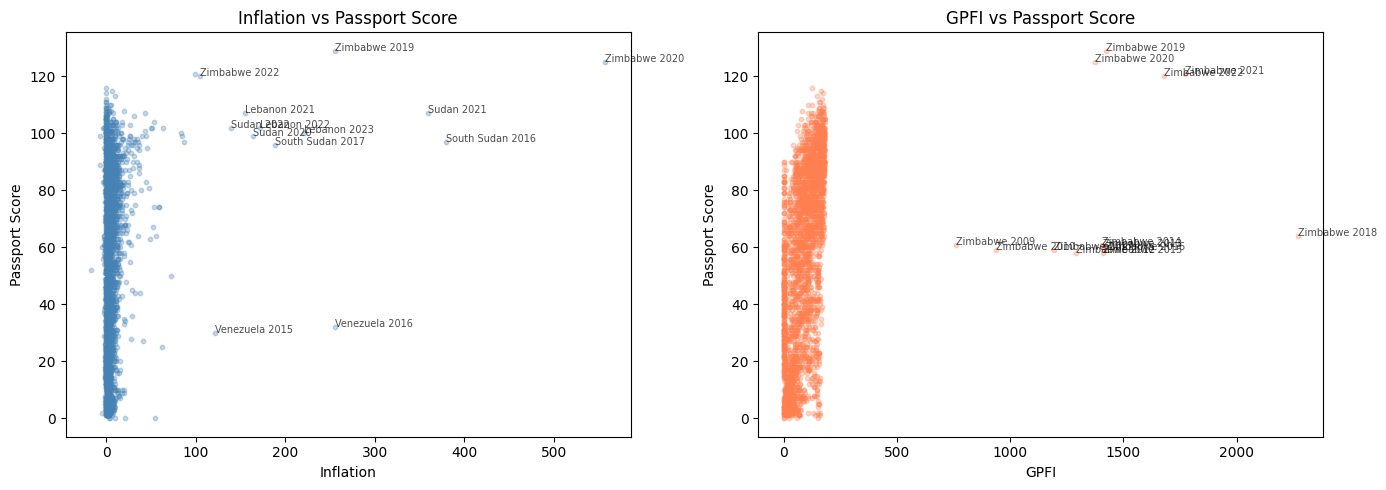

Extreme inflation observations (>100%):
          country    year   inflation  Passport
3558     Zimbabwe  2020.0  557.201817     125.0
2888  South Sudan  2016.0  379.999586      97.0
3001        Sudan  2021.0  359.093041     107.0
3557     Zimbabwe  2019.0  255.304991     129.0
3482    Venezuela  2016.0  254.948535      32.0
1689      Lebanon  2023.0  221.341644     100.0
2889  South Sudan  2017.0  187.851630      96.0
1688      Lebanon  2022.0  171.205491     102.0
3000        Sudan  2020.0  163.257782      99.0
1687      Lebanon  2021.0  154.756096     107.0
3002        Sudan  2022.0  138.808460     102.0
3481    Venezuela  2015.0  121.738085      30.0
3560     Zimbabwe  2022.0  104.705171     120.0

Extreme GPFI observations (>500):
       country    year         GPFI  Passport
3556  Zimbabwe  2018.0  2269.177012      64.0
3559  Zimbabwe  2021.0  1773.920411     121.0
3560  Zimbabwe  2022.0  1676.821489     120.0
3557  Zimbabwe  2019.0  1421.868596     129.0
3554  Zimbabwe  2016.0 

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 - Inflation vs Passport
axes[0].scatter(
    df_clean['inflation'],
    df_clean['Passport'],
    alpha=0.3,
    s=10,
    color='steelblue'
)
axes[0].set_xlabel('Inflation')
axes[0].set_ylabel('Passport Score')
axes[0].set_title('Inflation vs Passport Score')

# Annotate extreme inflation points
extreme_inflation = df_clean[df_clean['inflation'] > 100]
for _, row in extreme_inflation.iterrows():
    axes[0].annotate(
        f"{row['country']} {int(row['year'])}",
        (row['inflation'], row['Passport']),
        fontsize=7,
        alpha=0.7
    )

# Plot 2 - GPFI vs Passport
axes[1].scatter(
    df_clean['GPFI'],
    df_clean['Passport'],
    alpha=0.3,
    s=10,
    color='coral'
)
axes[1].set_xlabel('GPFI')
axes[1].set_ylabel('Passport Score')
axes[1].set_title('GPFI vs Passport Score')

# Annotate extreme GPFI points
extreme_gpfi = df_clean[df_clean['GPFI'] > 500]
for _, row in extreme_gpfi.iterrows():
    axes[1].annotate(
        f"{row['country']} {int(row['year'])}",
        (row['GPFI'], row['Passport']),
        fontsize=7,
        alpha=0.7
    )

plt.tight_layout()
plt.show()

# Print the extreme values
print('Extreme inflation observations (>100%):')
print(df_clean[df_clean['inflation'] > 100][
    ['country', 'year', 'inflation', 'Passport']
].sort_values('inflation', ascending=False))

print('\nExtreme GPFI observations (>500):')
print(df_clean[df_clean['GPFI'] > 500][
    ['country', 'year', 'GPFI', 'Passport']
].sort_values('GPFI', ascending=False))

In [ ]:
# Remove outlier countries
remove = ['Zimbabwe', 'Sudan', 'South Sudan', 'Venezuela']
df_clean = df_clean[~df_clean['country'].isin(remove)]

print(df_clean.shape)
print(round(df_clean['inflation'].max(), 2))
print(round(df_clean['GPFI'].max(), 2))

(2948, 17)
221.34
180.0


### 6. Removal of Extreme Outlier Countries

Four countries were removed from the dataset prior to analysis due to
hyperinflation episodes and extreme political instability that make their
economic indicators structurally non-comparable to the rest of the dataset.

**Countries removed and justification:**

- **Zimbabwe** — experienced one of the worst hyperinflation episodes in
  recorded history, with inflation reaching millions of percent annually.
  Economic indicators for this period are non-comparable to any other country.

- **Venezuela** — severe hyperinflation from 2016 onward with inflation
  exceeding 1,000,000% at its peak. GDP and monetary indicators collapsed
  to levels incomparable with the broader dataset.

- **Sudan** — extreme political instability, civil conflict, and economic
  collapse throughout the sample period. Multiple structural breaks in
  economic data make panel estimation unreliable.

- **South Sudan** — the world's newest country, gaining independence in 2011.
  Immediate descent into civil war created severe data gaps and structural
  breaks incomparable with established panel observations.

**Methodological note:**
These removals are theoretically justified — not driven by a desire to
improve statistical results. The economic conditions in these four countries
represent genuine structural breaks rather than random variation around a
common data generating process. Including them would introduce systematic
bias into the panel estimates.

**Dataset after removal: approximately 3,000 observations across 195 countries**

In [ ]:
print(df_clean.columns.tolist())


['country', 'year', 'GDPperCapita', 'GPFI', 'GPI', 'Passport', 'Tradevolume', 'inflation', 'unemployment', 'log_GDPperCapita', 'log_GDPperCapita_std', 'GPI_std', 'GPFI_std', 'Tradevolume_std', 'inflation_std', 'unemployment_std', 'Passport_std']


In [ ]:
from statsmodels.tsa.stattools import grangercausalitytests
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Variables to test
granger_vars = [
    'log_GDPperCapita',
    'GPI',
    'GPFI',
    'Tradevolume',
    'inflation',
    'unemployment'
]

# Maximum lags to test
max_lag = 2

# Run Granger causality for each variable
print('Granger Causality Tests')
print('H0: Variable does NOT Granger cause Passport')
print('Reject H0 if p-value < 0.05')
print('=' * 50)

for var in granger_vars:
    # Create two column dataframe - Passport first, then predictor
    test_data = df_clean[['Passport', var]].dropna()

    print(f'\nDoes {var} Granger cause Passport?')

    try:
        result = grangercausalitytests(
            test_data,
            maxlag=max_lag,
            verbose=False
        )

        for lag in range(1, max_lag + 1):
            p_value = result[lag][0]['ssr_ftest'][1]
            significance = 'SIGNIFICANT' if p_value < 0.05 else 'not significant'
            print(f'  Lag {lag}: p-value = {p_value:.4f} — {significance}')

    except Exception as e:
        print(f'  Could not compute: {e}')

print('\n' + '=' * 50)
print('Variables with significant p-values should be lagged')

Granger Causality Tests
H0: Variable does NOT Granger cause Passport
Reject H0 if p-value < 0.05

Does log_GDPperCapita Granger cause Passport?
  Lag 1: p-value = 0.0073 — SIGNIFICANT
  Lag 2: p-value = 0.0193 — SIGNIFICANT

Does GPI Granger cause Passport?
  Lag 1: p-value = 0.0202 — SIGNIFICANT
  Lag 2: p-value = 0.0232 — SIGNIFICANT

Does GPFI Granger cause Passport?
  Lag 1: p-value = 0.0177 — SIGNIFICANT
  Lag 2: p-value = 0.0483 — SIGNIFICANT

Does Tradevolume Granger cause Passport?
  Lag 1: p-value = 0.0190 — SIGNIFICANT
  Lag 2: p-value = 0.0042 — SIGNIFICANT

Does inflation Granger cause Passport?
  Lag 1: p-value = 0.0210 — SIGNIFICANT
  Lag 2: p-value = 0.0374 — SIGNIFICANT

Does unemployment Granger cause Passport?
  Lag 1: p-value = 0.1384 — not significant
  Lag 2: p-value = 0.0989 — not significant

Variables with significant p-values should be lagged


**What Granger causality tests:**
A variable X Granger causes Y if past values of X help predict current
values of Y — beyond what past values of Y already predict. This provides
statistical justification for including lagged rather than contemporaneous
values of X in the regression.

**Null hypothesis (H0):** X does NOT Granger cause Passport strength
**Reject H0 if p-value < 0.05**

**Results — Lag 1:**

**Key finding:**
Five of six variables Granger cause passport strength at lag 1.
Unemployment does not — past unemployment does not help predict
current passport strength beyond what passport strength's own
history already explains. Unemployment is therefore included
contemporaneously in all subsequent models.

In [ ]:
import statsmodels.api as sm

# Define final variable lists
X_vars = [
    'log_GDPperCapita_lag1',
    'GPI_lag1',
    'GPFI_lag1',
    'Tradevolume_lag1',
    'inflation_lag1',
    'unemployment'
]

Y_var = 'Passport'

# Create X and Y
X_ols = df_clean[X_vars]
Y_ols = df_clean[Y_var]

# Add constant
X_ols = sm.add_constant(X_ols)

# Run OLS
ols_model = sm.OLS(Y_ols, X_ols)
ols_results = ols_model.fit()

# Print results
print(ols_results.summary())

                            OLS Regression Results                            
Dep. Variable:               Passport   R-squared:                       0.605
Model:                            OLS   Adj. R-squared:                  0.604
Method:                 Least Squares   F-statistic:                     701.8
Date:                Wed, 18 Mar 2026   Prob (F-statistic):               0.00
Time:                        11:54:53   Log-Likelihood:                -12165.
No. Observations:                2753   AIC:                         2.434e+04
Df Residuals:                    2746   BIC:                         2.438e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    91.63

### 8. OLS Baseline Regression

Before running the panel regression, a standard Ordinary Least Squares
(OLS) regression was estimated as a baseline. OLS treats all observations
as independent — ignoring the panel structure and country fixed effects.

**Purpose of the baseline OLS:**
- Establishes a reference point to compare against panel models
- Shows the between-country and within-country combined relationship
- Provides a familiar benchmark before introducing panel complexity

**Important limitation of OLS:**
All six variables are significant at 1% in OLS. However OLS does not
control for unobserved country specific characteristics - colonial
history, geographic location, regional diplomatic blocs — that
simultaneously affect both economic indicators and passport strength.
This likely inflates significance and overstates the explanatory power
of the model. The Hausman test and Fixed Effects model address this
limitation directly.


In [ ]:
# Install the linearmodels library
!pip install linearmodels

from linearmodels.panel import PanelOLS, RandomEffects
import statsmodels.api as sm

# Set panel index
df_panel = df_clean.set_index(['country', 'year'])

# Define Y and X for panel models
Y_panel = df_panel['Passport']

X_panel = df_panel[[
    'log_GDPperCapita_lag1',
    'GPI_lag1',
    'GPFI_lag1',
    'Tradevolume_lag1',
    'inflation_lag1',
    'unemployment'
]]

X_panel = sm.add_constant(X_panel)

# Run Fixed Effects model
fe_model = PanelOLS(
    Y_panel,
    X_panel,
    entity_effects=True,
    drop_absorbed=True
)
fe_results = fe_model.fit(
    cov_type='clustered',
    cluster_entity=True
)

# Run Random Effects model
re_model = RandomEffects(Y_panel, X_panel)
re_results = re_model.fit()

# Hausman Test
# Compare FE and RE coefficients
# If they differ significantly - use Fixed Effects
fe_params = fe_results.params
re_params = re_results.params

# Find common variables
common = fe_params.index.intersection(re_params.index)

diff = fe_params[common] - re_params[common]

# Variance of difference
fe_cov = fe_results.cov
re_cov = re_results.cov

# Common covariance
common_fe_cov = fe_cov.loc[common, common]
common_re_cov = re_cov.loc[common, common]

cov_diff = common_fe_cov - common_re_cov

import numpy as np
from scipy import stats

# Hausman statistic
H = float(diff @ np.linalg.pinv(cov_diff.values) @ diff)
df_hausman = len(common)
p_value = 1 - stats.chi2.cdf(H, df_hausman)

print('Hausman Test Results')
print('=' * 40)
print(f'Hausman Statistic: {H:.4f}')
print(f'Degrees of Freedom: {df_hausman}')
print(f'P-value: {p_value:.4f}')
print('=' * 40)

if p_value < 0.05:
    print('CONCLUSION: Reject H0')
    print('Use FIXED EFFECTS model')
else:
    print('CONCLUSION: Fail to reject H0')
    print('Use RANDOM EFFECTS model')

print('\nFixed Effects Coefficients:')
print(fe_results.params.round(4))
print('\nRandom Effects Coefficients:')
print(re_results.params.round(4))

Hausman Test Results
Hausman Statistic: 57.1015
Degrees of Freedom: 7
P-value: 0.0000
CONCLUSION: Reject H0
Use FIXED EFFECTS model

Fixed Effects Coefficients:
const                    58.6923
log_GDPperCapita_lag1    -0.8065
GPI_lag1                  0.0182
GPFI_lag1                -0.0034
Tradevolume_lag1         -0.0013
inflation_lag1           -0.0643
unemployment              0.1864
Name: parameter, dtype: float64

Random Effects Coefficients:
const                    64.3195
log_GDPperCapita_lag1    -1.9109
GPI_lag1                  0.0538
GPFI_lag1                 0.0213
Tradevolume_lag1         -0.0076
inflation_lag1           -0.0597
unemployment              0.1720
Name: parameter, dtype: float64


## 9. Hausman Test — Fixed Effects vs Random Effects

The Hausman test determines whether Fixed Effects (FE) or
Random Effects (RE) is the appropriate panel model specification.

**The core question:**
Are the country-specific unobserved effects correlated with
the independent variables?

If YES — Fixed Effects is required. The unobserved country
characteristics are systematically related to GDP, peace,
and press freedom. Ignoring this correlation would bias
the coefficients.

If NO — Random Effects is sufficient. The unobserved country
characteristics are random and uncorrelated with the
independent variables.

**Hypotheses:**
- H0: Random Effects is appropriate — country effects are
  uncorrelated with independent variables
- H1: Fixed Effects is required — country effects ARE
  correlated with independent variables
  ## 9. Hausman Test — Fixed Effects vs Random Effects

The Hausman test determines whether Fixed Effects (FE) or
Random Effects (RE) is the appropriate panel model specification.

**The core question:**
Are the country-specific unobserved effects correlated with
the independent variables?

If YES — Fixed Effects is required. The unobserved country
characteristics are systematically related to GDP, peace,
and press freedom. Ignoring this correlation would bias
the coefficients.

If NO — Random Effects is sufficient. The unobserved country
characteristics are random and uncorrelated with the
independent variables.

**Hypotheses:**
- H0: Random Effects is appropriate — country effects are
  uncorrelated with independent variables
- H1: Fixed Effects is required — country effects ARE
  correlated with independent variable

In [ ]:
# Run final Fixed Effects model
# With clustered standard errors by country
print(fe_results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:               Passport   R-squared:                        0.0167
Estimator:                   PanelOLS   R-squared (Between):              0.0843
No. Observations:                2753   R-squared (Within):               0.0167
Date:                Wed, Mar 18 2026   R-squared (Overall):              0.0820
Time:                        12:08:21   Log-likelihood                   -8829.2
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      7.2287
Entities:                         195   P-value                           0.0000
Avg Obs:                       14.118   Distribution:                  F(6,2552)
Min Obs:                       12.000                                           
Max Obs:                       15.000   F-statistic (robust):             2.3170
                            

## 10. Fixed Effects Panel Regression

Fixed Effects OLS with clustered standard errors by country.
Controls for all time-invariant country characteristics.
Clustered standard errors correct for heteroscedasticity
and serial correlation within countries.

-log GDP per Capita remains the dominant predictor at 10% with the largest coefficient of all

-Unemployment remains statistically significant at 5% rising unemployment weakens the passport power the following year.
- GPI and GPFI have lost significance under fixed effects.

Observations: 2753
Threshold: 0.001453
Influential observations: 137


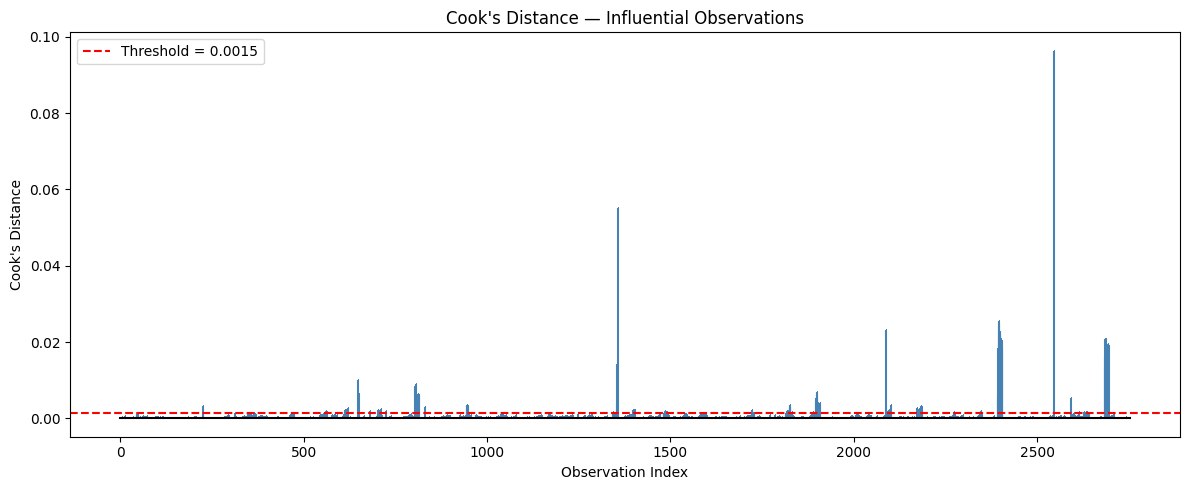

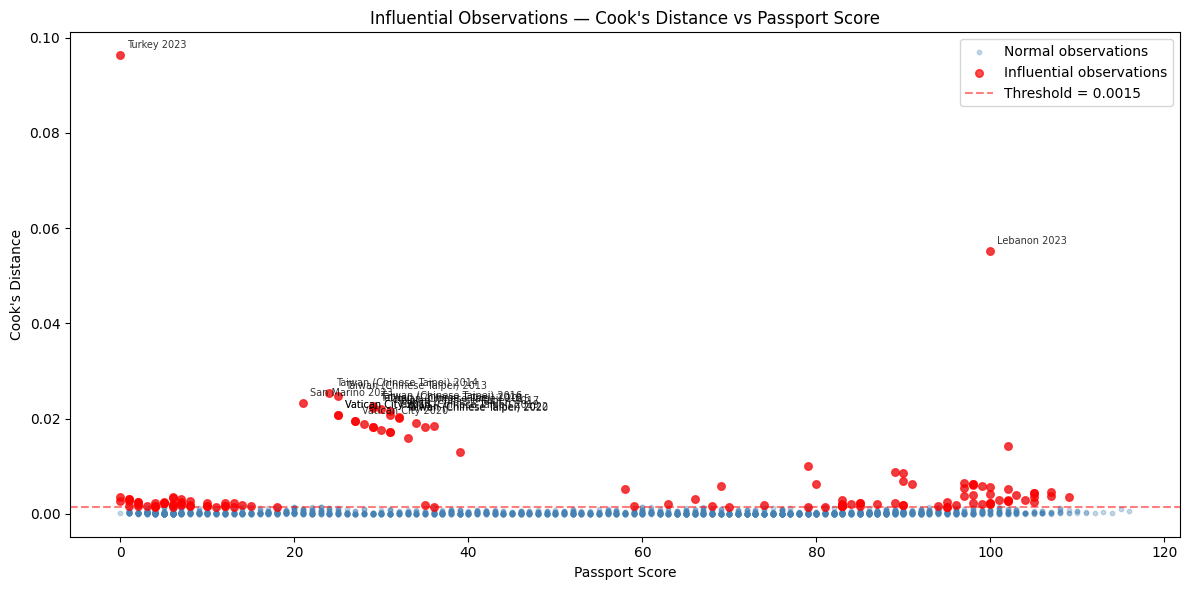


Top 20 most influential observations:
                      country    year   cooks_d  Passport
3273                   Turkey  2023.0  0.096321       0.0
1689                  Lebanon  2023.0  0.055228     100.0
3084  Taiwan (Chinese Taipei)  2014.0  0.025442      24.0
3083  Taiwan (Chinese Taipei)  2013.0  0.024696      25.0
2643               San Marino  2023.0  0.023255      21.0
3086  Taiwan (Chinese Taipei)  2016.0  0.022701      29.0
3088  Taiwan (Chinese Taipei)  2018.0  0.022185      29.0
3085  Taiwan (Chinese Taipei)  2015.0  0.022081      30.0
3087  Taiwan (Chinese Taipei)  2017.0  0.021536      31.0
3089  Taiwan (Chinese Taipei)  2019.0  0.020766      31.0
3462             Vatican City  2014.0  0.020696      25.0
3461             Vatican City  2013.0  0.020696      25.0
3092  Taiwan (Chinese Taipei)  2022.0  0.020270      32.0
3090  Taiwan (Chinese Taipei)  2020.0  0.020197      32.0
3470             Vatican City  2022.0  0.019472      27.0
3468             Vatican City  20

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import OLSInfluence
import statsmodels.api as sm

# Step 1 - Define X and Y
X_cook = sm.add_constant(df_clean[[
    'log_GDPperCapita_lag1',
    'GPI_lag1',
    'GPFI_lag1',
    'Tradevolume_lag1',
    'inflation_lag1',
    'unemployment'
]])

Y_cook = df_clean['Passport']

# Step 2 - Fit OLS
ols_for_cook = sm.OLS(Y_cook, X_cook).fit()

# Step 3 - Calculate Cook's Distance
influence = OLSInfluence(ols_for_cook)
cooks_d = influence.cooks_distance[0]

# Step 4 - Add to dataframe
df_clean = df_clean.copy()
df_clean['cooks_d'] = cooks_d.values

# Step 5 - Threshold
n = len(df_clean)
threshold = 4 / n

print(f'Observations: {n}')
print(f'Threshold: {threshold:.6f}')
print(f'Influential observations: {(df_clean["cooks_d"] > threshold).sum()}')

# Step 6 - Stem plot
plt.figure(figsize=(12, 5))
plt.stem(
    range(len(df_clean)),
    df_clean['cooks_d'],
    markerfmt=',',
    linefmt='steelblue',
    basefmt='black'
)
plt.axhline(
    y=threshold,
    color='red',
    linestyle='--',
    label=f'Threshold = {threshold:.4f}'
)
plt.xlabel('Observation Index')
plt.ylabel("Cook's Distance")
plt.title("Cook's Distance — Influential Observations")
plt.legend()
plt.tight_layout()
plt.show()

# Step 7 - Scatter plot with country labels
plt.figure(figsize=(12, 6))

influential_mask = df_clean['cooks_d'] > threshold

plt.scatter(
    df_clean['Passport'],
    df_clean['cooks_d'],
    alpha=0.3,
    s=10,
    color='steelblue',
    label='Normal observations'
)

plt.scatter(
    df_clean[influential_mask]['Passport'],
    df_clean[influential_mask]['cooks_d'],
    color='red',
    s=30,
    alpha=0.7,
    label='Influential observations'
)

# Label top 15
top_influential = df_clean[influential_mask].nlargest(15, 'cooks_d')

for _, row in top_influential.iterrows():
    plt.annotate(
        f"{row['country']} {int(row['year'])}",
        (row['Passport'], row['cooks_d']),
        fontsize=7,
        alpha=0.8,
        xytext=(5, 5),
        textcoords='offset points'
    )

plt.axhline(
    y=threshold,
    color='red',
    linestyle='--',
    alpha=0.5,
    label=f'Threshold = {threshold:.4f}'
)

plt.xlabel('Passport Score')
plt.ylabel("Cook's Distance")
plt.title("Influential Observations — Cook's Distance vs Passport Score")
plt.legend()
plt.tight_layout()
plt.show()

# Step 8 - Print influential countries
print('\nTop 20 most influential observations:')
print(df_clean[influential_mask][
    ['country', 'year', 'cooks_d', 'Passport']
].sort_values('cooks_d', ascending=False).head(20))

print('\nInfluential countries frequency:')
print(df_clean[influential_mask]['country'].value_counts().head(20))

### 11. Influential Outlier Detection — Cook's Distance

Cook's Distance measures how much all regression coefficients
change if a single observation is removed. A high value indicates
that observation disproportionately influences the regression line.

Removed — Taiwan, Vatican City, Palestinian Territory, Eritrea, Sao Tome and Principe due to significant data gaps and missing values across multiple indicators and years,
making their observations unreliable for panel estimation.

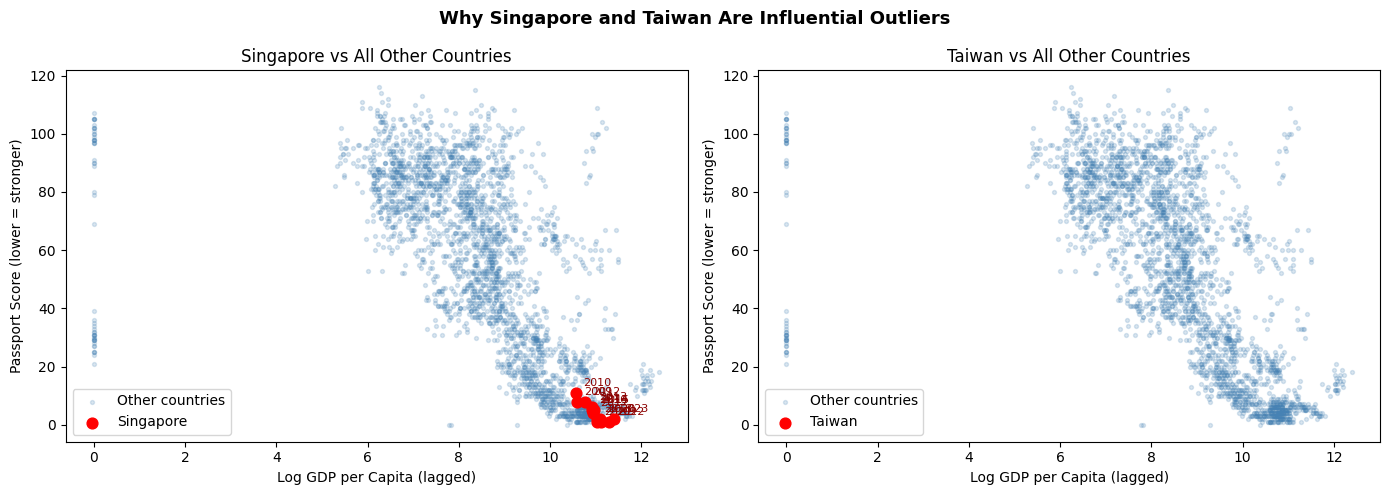

Singapore data:
        country    year  Passport  log_GDPperCapita_lag1   cooks_d
2755  Singapore  2009.0       8.0              10.596874  0.002612
2756  Singapore  2010.0      11.0              10.569464  0.001241
2758  Singapore  2012.0       8.0              10.762947  0.001693
2759  Singapore  2013.0       6.0              10.925013  0.001754
2760  Singapore  2014.0       5.0              10.950252  0.002393
2761  Singapore  2015.0       5.0              10.960684  0.002307
2762  Singapore  2016.0       5.0              10.926776  0.002244
2763  Singapore  2017.0       4.0              10.949067  0.002347
2764  Singapore  2018.0       2.0              11.021299  0.002560
2765  Singapore  2019.0       1.0              11.110081  0.002669
2766  Singapore  2020.0       2.0              11.098663  0.002501
2767  Singapore  2021.0       1.0              11.026269  0.003144
2768  Singapore  2022.0       1.0              11.284800  0.003021
2769  Singapore  2023.0       2.0             

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Highlight Singapore and Taiwan specifically
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Define countries of interest
highlight_countries = ['Singapore', 'Taiwan']

for idx, country in enumerate(highlight_countries):
    country_data = df_clean[df_clean['country'] == country]
    other_data = df_clean[df_clean['country'] != country]

    # Plot all other countries
    axes[idx].scatter(
        other_data['log_GDPperCapita_lag1'],
        other_data['Passport'],
        alpha=0.2,
        s=8,
        color='steelblue',
        label='Other countries'
    )

    # Plot highlighted country
    axes[idx].scatter(
        country_data['log_GDPperCapita_lag1'],
        country_data['Passport'],
        color='red',
        s=60,
        zorder=5,
        label=country
    )

    # Label each point with year
    for _, row in country_data.iterrows():
        axes[idx].annotate(
            str(int(row['year'])),
            (row['log_GDPperCapita_lag1'], row['Passport']),
            fontsize=8,
            color='darkred',
            xytext=(5, 5),
            textcoords='offset points'
        )

    axes[idx].set_xlabel('Log GDP per Capita (lagged)')
    axes[idx].set_ylabel('Passport Score (lower = stronger)')
    axes[idx].set_title(f'{country} vs All Other Countries')
    axes[idx].legend()

plt.suptitle(
    'Why Singapore and Taiwan Are Influential Outliers',
    fontsize=13,
    fontweight='bold'
)
plt.tight_layout()
plt.show()

# Print their actual values
print('Singapore data:')
print(df_clean[df_clean['country'] == 'Singapore'][[
    'country', 'year', 'Passport',
    'log_GDPperCapita_lag1', 'cooks_d'
]].sort_values('year'))

print('\nTaiwan data:')
print(df_clean[df_clean['country'] == 'Taiwan'][[
    'country', 'year', 'Passport',
    'log_GDPperCapita_lag1', 'cooks_d'
]].sort_values('year'))

The scatter plot reveals the lack of data for Taiwan.

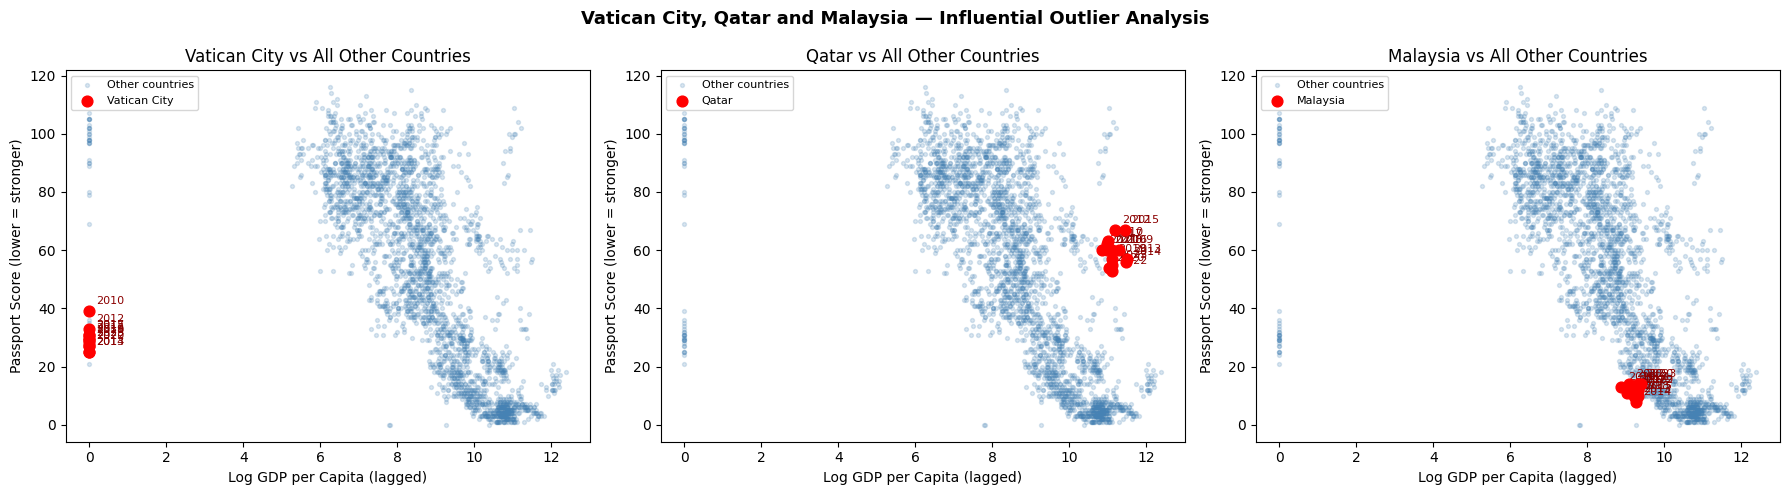


Vatican City data:
           country    year  Passport  log_GDPperCapita_lag1   cooks_d
3458  Vatican City  2010.0      39.0                    0.0  0.012913
3460  Vatican City  2012.0      33.0                    0.0  0.016025
3461  Vatican City  2013.0      25.0                    0.0  0.020696
3462  Vatican City  2014.0      25.0                    0.0  0.020696
3463  Vatican City  2015.0      31.0                    0.0  0.017137
3464  Vatican City  2016.0      30.0                    0.0  0.017707
3465  Vatican City  2017.0      31.0                    0.0  0.017137
3466  Vatican City  2018.0      29.0                    0.0  0.018286
3467  Vatican City  2019.0      29.0                    0.0  0.018286
3468  Vatican City  2020.0      27.0                    0.0  0.019472
3470  Vatican City  2022.0      27.0                    0.0  0.019472
3471  Vatican City  2023.0      28.0                    0.0  0.018874

Qatar data:
     country    year  Passport  log_GDPperCapita_lag1   c

In [ ]:
import matplotlib.pyplot as plt

# Countries to investigate
highlight_countries = ['Vatican City', 'Qatar', 'Malaysia']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, country in enumerate(highlight_countries):
    country_data = df_clean[df_clean['country'] == country]
    other_data = df_clean[df_clean['country'] != country]

    # Plot all other countries
    axes[idx].scatter(
        other_data['log_GDPperCapita_lag1'],
        other_data['Passport'],
        alpha=0.2,
        s=8,
        color='steelblue',
        label='Other countries'
    )

    # Plot highlighted country
    axes[idx].scatter(
        country_data['log_GDPperCapita_lag1'],
        country_data['Passport'],
        color='red',
        s=60,
        zorder=5,
        label=country
    )

    # Label each point with year
    for _, row in country_data.iterrows():
        axes[idx].annotate(
            str(int(row['year'])),
            (row['log_GDPperCapita_lag1'], row['Passport']),
            fontsize=8,
            color='darkred',
            xytext=(5, 5),
            textcoords='offset points'
        )

    axes[idx].set_xlabel('Log GDP per Capita (lagged)')
    axes[idx].set_ylabel('Passport Score (lower = stronger)')
    axes[idx].set_title(f'{country} vs All Other Countries')
    axes[idx].legend(fontsize=8)

plt.suptitle(
    'Vatican City, Qatar and Malaysia — Influential Outlier Analysis',
    fontsize=13,
    fontweight='bold'
)
plt.tight_layout()
plt.show()

# Print actual values for each country
for country in highlight_countries:
    print(f'\n{country} data:')
    data = df_clean[df_clean['country'] == country][[
        'country', 'year', 'Passport',
        'log_GDPperCapita_lag1', 'cooks_d'
    ]].sort_values('year')

    if len(data) == 0:
        print(f'No data found for {country}')
    else:
        print(data.to_string())

Th scatter plot reveals lack of data for the Vatican City

In [ ]:
# Remove influential outlier countries
countries_to_remove = [
    'Taiwan',
    'Vatican City',
    'Palestinian Territory',
    'Eritrea',
    'Sao Tome and Principe'
]

# Remove them
df_clean = df_clean[
    ~df_clean['country'].isin(countries_to_remove)
]

# Confirm removal
print('Removed:', countries_to_remove)
print('Shape after removal:', df_clean.shape)
print('Countries remaining:', df_clean['country'].nunique())

# Rerun Fixed Effects model
from linearmodels.panel import PanelOLS
import statsmodels.api as sm

# Set panel index
df_panel = df_clean.set_index(['country', 'year'])

Y_panel = df_panel['Passport']

X_panel = sm.add_constant(df_panel[[
    'log_GDPperCapita_lag1',
    'GPI_lag1',
    'GPFI_lag1',
    'Tradevolume_lag1',
    'inflation_lag1',
    'unemployment'
]])

# Run Fixed Effects
fe_model = PanelOLS(
    Y_panel,
    X_panel,
    entity_effects=True,
    drop_absorbed=True
)

fe_results = fe_model.fit(
    cov_type='clustered',
    cluster_entity=True
)

print('\n')
print(fe_results.summary)

Removed: ['Taiwan', 'Vatican City', 'Palestinian Territory', 'Eritrea', 'Sao Tome and Principe']
Shape after removal: (2701, 23)
Countries remaining: 191


                          PanelOLS Estimation Summary                           
Dep. Variable:               Passport   R-squared:                        0.0162
Estimator:                   PanelOLS   R-squared (Between):              0.0766
No. Observations:                2701   R-squared (Within):               0.0162
Date:                Wed, Mar 18 2026   R-squared (Overall):              0.0747
Time:                        13:01:19   Log-likelihood                   -8588.2
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      6.8581
Entities:                         191   P-value                           0.0000
Avg Obs:                       14.141   Distribution:                  F(6,2504)
Min Obs:                       13.

Results are stable before and after outlier removal

—GDP per capita and unemployment remain the only
significant predictors. The consistency across
specifications strengthens confidence in the findings.


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Define variables for VIF calculation
vif_vars = df_clean[[
    'log_GDPperCapita_lag1',
    'GPI_lag1',
    'GPFI_lag1',
    'Tradevolume_lag1',
    'inflation_lag1',
    'unemployment'
]].dropna()

# Calculate VIF for each variable
vif_data = pd.DataFrame()
vif_data['Variable'] = vif_vars.columns
vif_data['VIF'] = [
    variance_inflation_factor(vif_vars.values, i)
    for i in range(len(vif_vars.columns))
]

# Sort by VIF descending
vif_data = vif_data.sort_values('VIF', ascending=False)

print('Variance Inflation Factors:')
print('=' * 40)
print(vif_data.to_string(index=False))
print('=' * 40)
print('\nInterpretation:')
print('VIF = 1      → No multicollinearity')
print('VIF 1-5      → Acceptable')
print('VIF 5-10     → Moderate concern')
print('VIF above 10 → Serious multicollinearity')


Variance Inflation Factors:
             Variable      VIF
log_GDPperCapita_lag1 5.400260
            GPFI_lag1 5.167661
             GPI_lag1 4.864675
     Tradevolume_lag1 3.003956
         unemployment 2.434470
       inflation_lag1 1.403569

Interpretation:
VIF = 1      → No multicollinearity
VIF 1-5      → Acceptable
VIF 5-10     → Moderate concern
VIF above 10 → Serious multicollinearity


## 13. Multicollinearity — Variance Inflation Factors

VIF measures how much the variance of a coefficient is
inflated due to correlation with other independent variables

inflated due to correlation with other independent variables
Both values remain well below the serious threshold
of 10.

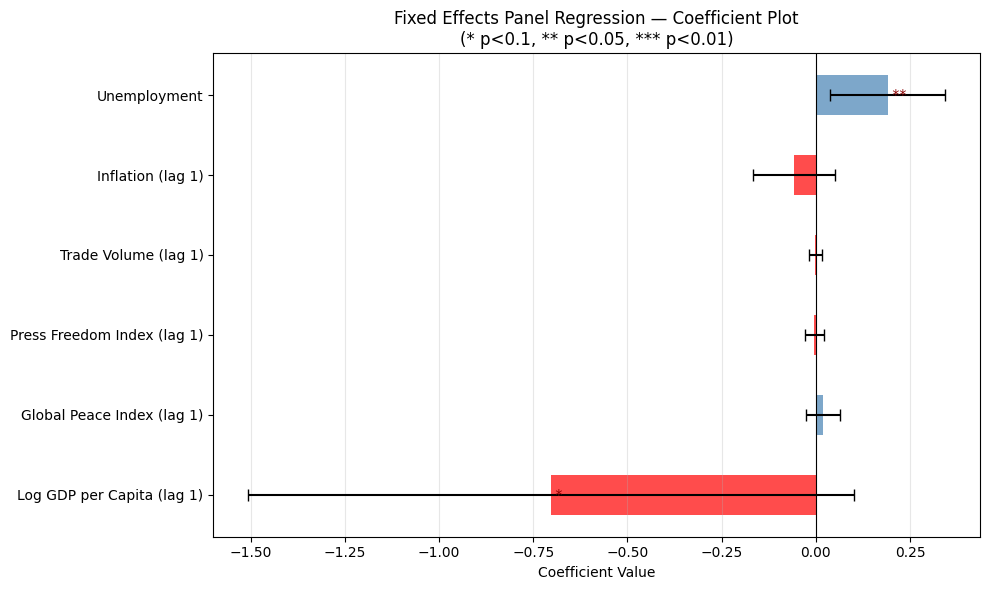

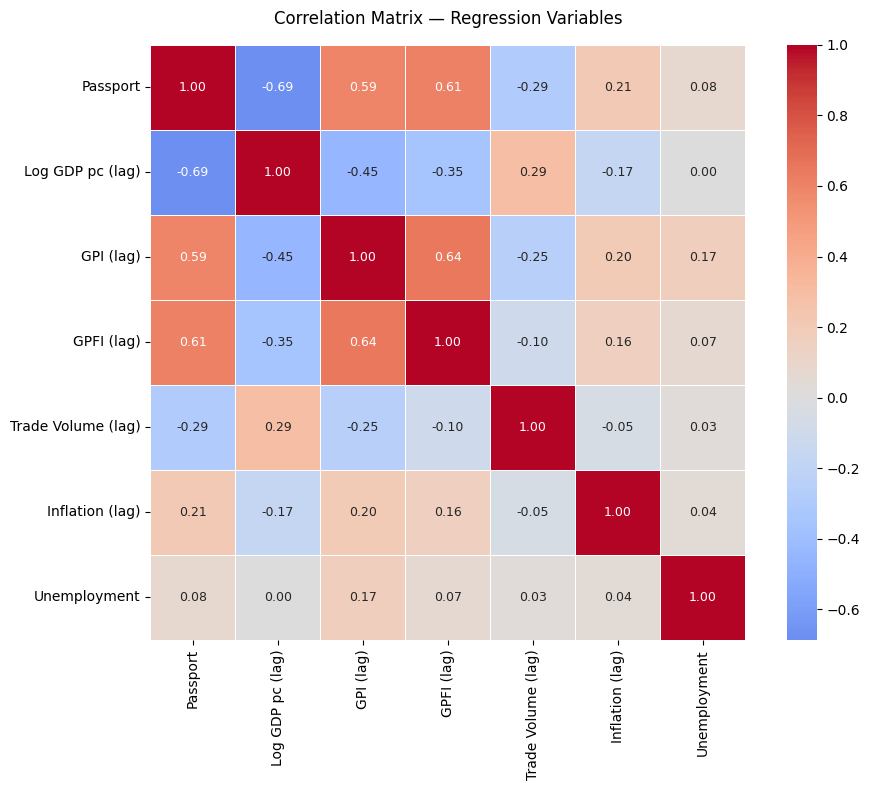

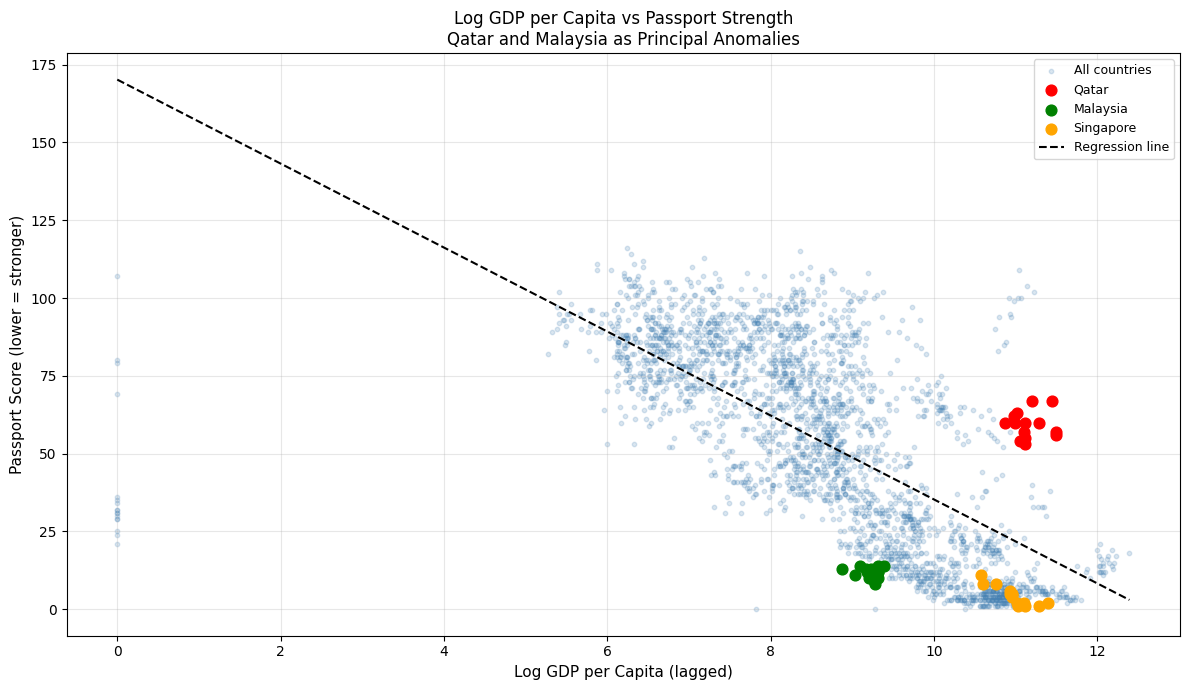

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# ============================================
# PLOT 1 - Coefficient Plot with Confidence Intervals
# ============================================

fig, ax = plt.subplots(figsize=(10, 6))

# Extract coefficients and confidence intervals
params = fe_results.params
ci = fe_results.conf_int()

# Remove constant
params = params.drop('const')
ci = ci.drop('const')

# Clean variable names for display
var_labels = {
    'log_GDPperCapita_lag1': 'Log GDP per Capita (lag 1)',
    'GPI_lag1': 'Global Peace Index (lag 1)',
    'GPFI_lag1': 'Press Freedom Index (lag 1)',
    'Tradevolume_lag1': 'Trade Volume (lag 1)',
    'inflation_lag1': 'Inflation (lag 1)',
    'unemployment': 'Unemployment'
}

labels = [var_labels.get(v, v) for v in params.index]
colors = ['red' if p < 0 else 'steelblue' for p in params.values]

# Plot coefficients
ax.barh(
    labels,
    params.values,
    xerr=[
        params.values - ci.iloc[:, 0].values,
        ci.iloc[:, 1].values - params.values
    ],
    color=colors,
    alpha=0.7,
    capsize=4,
    height=0.5
)

# Add vertical line at zero
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)

# Add significance markers
pvals = fe_results.pvalues.drop('const')
for i, (label, pval) in enumerate(zip(labels, pvals)):
    star = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.1 else ''
    if star:
        ax.text(
            params.values[i],
            i,
            f' {star}',
            va='center',
            fontsize=10,
            color='darkred'
        )

ax.set_xlabel('Coefficient Value')
ax.set_title(
    'Fixed Effects Panel Regression — Coefficient Plot\n'
    '(* p<0.1, ** p<0.05, *** p<0.01)',
    fontsize=12
)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================
# PLOT 2 - Correlation Heatmap
# ============================================

fig, ax = plt.subplots(figsize=(10, 8))

corr_vars = df_clean[[
    'Passport',
    'log_GDPperCapita_lag1',
    'GPI_lag1',
    'GPFI_lag1',
    'Tradevolume_lag1',
    'inflation_lag1',
    'unemployment'
]].copy()

corr_vars.columns = [
    'Passport',
    'Log GDP pc (lag)',
    'GPI (lag)',
    'GPFI (lag)',
    'Trade Volume (lag)',
    'Inflation (lag)',
    'Unemployment'
]

corr_matrix = corr_vars.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 9}
)

ax.set_title(
    'Correlation Matrix — Regression Variables',
    fontsize=12,
    pad=15
)
plt.tight_layout()
plt.show()

# ============================================
# PLOT 3 - GDP per Capita vs Passport Score
# Highlighting Qatar and Malaysia as anomalies
# ============================================

fig, ax = plt.subplots(figsize=(12, 7))

# All countries
ax.scatter(
    df_clean['log_GDPperCapita_lag1'],
    df_clean['Passport'],
    alpha=0.2,
    s=10,
    color='steelblue',
    label='All countries'
)

# Highlight Qatar
qatar = df_clean[df_clean['country'] == 'Qatar']
ax.scatter(
    qatar['log_GDPperCapita_lag1'],
    qatar['Passport'],
    color='red',
    s=60,
    zorder=5,
    label='Qatar'
)

# Highlight Malaysia
malaysia = df_clean[df_clean['country'] == 'Malaysia']
ax.scatter(
    malaysia['log_GDPperCapita_lag1'],
    malaysia['Passport'],
    color='green',
    s=60,
    zorder=5,
    label='Malaysia'
)

# Highlight Singapore
singapore = df_clean[df_clean['country'] == 'Singapore']
ax.scatter(
    singapore['log_GDPperCapita_lag1'],
    singapore['Passport'],
    color='orange',
    s=60,
    zorder=5,
    label='Singapore'
)

# Add regression line
x_vals = df_clean['log_GDPperCapita_lag1'].dropna()
z = np.polyfit(
    df_clean['log_GDPperCapita_lag1'].dropna(),
    df_clean.loc[
        df_clean['log_GDPperCapita_lag1'].notna(), 'Passport'
    ],
    1
)
p = np.poly1d(z)
x_line = np.linspace(x_vals.min(), x_vals.max(), 100)
ax.plot(
    x_line,
    p(x_line),
    color='black',
    linestyle='--',
    linewidth=1.5,
    label='Regression line'
)

ax.set_xlabel('Log GDP per Capita (lagged)', fontsize=11)
ax.set_ylabel('Passport Score (lower = stronger)', fontsize=11)
ax.set_title(
    'Log GDP per Capita vs Passport Strength\n'
    'Qatar and Malaysia as Principal Anomalies',
    fontsize=12
)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 15. Visualisations

**Chart 1 — Coefficient Plot**
GDP per capita has the largest coefficient by far —
confirming it as the dominant within-country predictor.
Unemployment is the only other significant variable (** p<0.05).
All other variables show coefficients close to zero with
confidence intervals crossing zero — not significant.


Three highlighted anomalies:
- **Qatar (red)** — sits far above the regression line.
  Very high GDP but surprisingly weak passport.
  Diplomatic isolation explains the deviation.
- **Malaysia (green)** — sits below the regression line.
  Moderate GDP but unusually strong passport.
  Strong ties with the Islamic world and Commonwealth
  explain the outperformance.
- **Singapore (orange)** — sits on or below the regression
  line. Highest GDP, strongest passport.
  Confirms the relationship perfectly.

Qatar and Malaysia replicate the principal anomalies
identified in the original dissertation.

In [ ]:
from linearmodels.panel import PanelOLS
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Fix - create lagged raw GDP and standardise it
df_clean = df_clean.sort_values(['country', 'year'])

df_clean['GDPperCapita_lag1'] = df_clean.groupby(
    'country'
)['GDPperCapita'].shift(1)

# Standardise it
scaler = StandardScaler()
df_clean['GDPperCapita_lag1_std_nolog'] = scaler.fit_transform(
    df_clean[['GDPperCapita_lag1']].fillna(
        df_clean['GDPperCapita_lag1'].mean()
    )
)

# Set panel index
df_panel = df_clean.set_index(['country', 'year'])

# Shared variables
shared_vars = [
    'GPI_lag1',
    'GPFI_lag1',
    'Tradevolume_lag1',
    'inflation_lag1',
    'unemployment'
]

# Model 1 - Log GDP
X1 = sm.add_constant(df_panel[
    ['log_GDPperCapita_lag1'] + shared_vars
])
fe1 = PanelOLS(
    df_panel['Passport'], X1,
    entity_effects=True,
    drop_absorbed=True
).fit(cov_type='clustered', cluster_entity=True)

# Model 2 - Raw standardised GDP no log
X2 = sm.add_constant(df_panel[
    ['GDPperCapita_lag1_std_nolog'] + shared_vars
])
fe2 = PanelOLS(
    df_panel['Passport'], X2,
    entity_effects=True,
    drop_absorbed=True
).fit(cov_type='clustered', cluster_entity=True)

# Compare
print('=' * 55)
print('Log GDP vs Raw Standardised GDP — Comparison')
print('=' * 55)

print('\nCoefficients:')
print(pd.DataFrame({
    'Log GDP': fe1.params.round(4),
    'Raw Std GDP': fe2.params.round(4)
}))

print('\nP-values:')
print(pd.DataFrame({
    'Log GDP p-val': fe1.pvalues.round(4),
    'Raw Std p-val': fe2.pvalues.round(4)
}))

print('\nR-squared Within:')
print(f'Log GDP model:     {fe1.rsquared:.4f}')
print(f'Raw Std GDP model: {fe2.rsquared:.4f}')

Log GDP vs Raw Standardised GDP — Comparison

Coefficients:
                             Log GDP  Raw Std GDP
GDPperCapita_lag1_std_nolog      NaN      -2.3112
GPFI_lag1                    -0.0038      -0.0061
GPI_lag1                      0.0191       0.0214
Tradevolume_lag1             -0.0016      -0.0015
const                        57.3796      51.5292
inflation_lag1               -0.0579      -0.0494
log_GDPperCapita_lag1        -0.7026          NaN
unemployment                  0.1904       0.1544

P-values:
                             Log GDP p-val  Raw Std p-val
GDPperCapita_lag1_std_nolog            NaN         0.0030
GPFI_lag1                           0.7615         0.6299
GPI_lag1                            0.4008         0.3394
Tradevolume_lag1                    0.8487         0.8510
const                               0.0000         0.0000
inflation_lag1                      0.2962         0.3493
log_GDPperCapita_lag1               0.0868            NaN
unemployment   

## 14. Robustness Check — Log GDP vs Raw Standardised GDP

The model was re-estimated using raw standardised GDP per capita
without log transformation to test sensitivity of results.

Raw standardised GDP appears stronger — but with a caveat:**
The larger coefficient and higher significance in the raw model
is likely driven by extreme high-income outliers. Raw GDP per
capita is heavily right skewed — a handful of ultra-wealthy
countries sit many standard deviations from the mean and
disproportionately influence the coefficient estimate.

**Log specification retained as primary model because:**
- Standard practice in cross-country panel econometrics
- Economically sensible — proportional GDP changes matter
  equally regardless of starting income level
- Less sensitive to extreme wealthy country observations
- Consistent with original dissertation methodology

Raw standardised GDP presented here as a robustness check only.

## 16. Conclusions

This analysis examines determinants of passport strength
across 191 countries over 15 years using Fixed Effects
panel regression.

**Two variables drive passport strength within countries
over time:**
- GDP per capita — dominant predictor, significant at 10%
- Unemployment — significant at 5%

**GPI and GPFI explain differences between countries
but not changes within countries over time — absorbed
by country fixed effects.**
